# Flow Matching

A simple example implementation of Flow Matching, for the purposes of a tutorial. Not optimized for performance. Written for clarity.

Reference: [Lipman *et al.* (2022), "Flow Matching for Generative Modeling", arXiv:2210.02747](https://arxiv.org/abs/2210.02747)

Install dependencies:

In [ ]:
! pip3 install tensorflow tensorflow_probability dm-sonnet \
               numpy matplotlib tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 20.3 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import sonnet as snt

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi': 150,
})

from tqdm.auto import tqdm

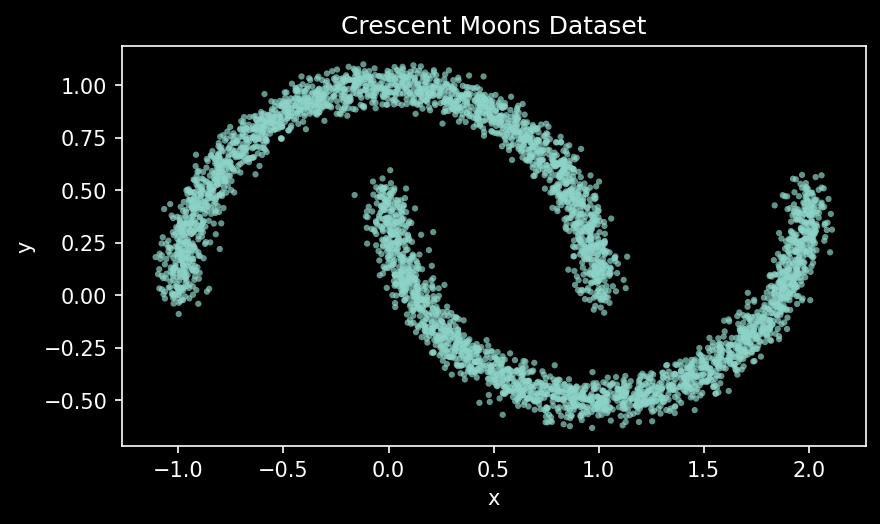

In [ ]:
# Make crescent moons dataset
from sklearn.datasets import make_moons

n_dim = 2
n_train = 1024*4
y_train,_ = make_moons(n_samples=n_train, noise=0.05, random_state=42)
y_train = y_train.astype('f4') # Ensure 32-bit floats for TensorFlow

plt.scatter(y_train[:, 0], y_train[:, 1], s=9, alpha=0.7, edgecolors='none')
plt.title("Crescent Moons Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()

## Continuous normalizing flows

Reference: [Grathwohl *et al* (2018), "FFJORD: Free-form Continuous Dynamics for Scalable Reversible Generative Models", arXiv:1810.01367](https://arxiv.org/abs/1810.01367).

As the name suggests, continuous normalizing flows use a continuous transformation, rather than a set of discrete transformation. This continuous transformation can be seen as the limit of an infinite number of infinitesimal transformations.

The actual transformation rule is inspired by physics, and is essentially a path defined by a velocity field. One defines a velocity field $\vec{v}(\vec{z}, t)$ (with the same dimensionality as $\vec{x}$) that depends on position $\vec{z}$ and a "time" variable $t$. One initializes $\vec{z}(0) = \vec{x}$, and then integrates it forward to time $t = 1$ by following the path defined by the velocity field:
$$
\frac{d\vec{z}(t)}{dt} = \vec{v}(\vec{z}(t), t)
$$
The result of the transformation is defined as $\vec{y} = \vec{z}(1)$.

The inverse transformation, from $\vec{y}$ to $\vec{x}$, is easy to define. One simply integrates the path through the velocity field backwards in time, starting from $\vec{z}(1) = \vec{y}$ and integrating back to $t = 0$. As long as the velocity field $\vec{v}$ is Lifshitz-continuous, the transformation is guaranteed to be invertible.

In order to calculate the probability of the point $\vec{y}$ using the change-of-variables formula, we need to calculate the determinant of the Jacobian of the transformation. This turns out to be easy to calculate, as well. The determinant is given by integrating the trace of the Jacobian of the velocity field along the path:
$$
  \log \left| \det \left( \frac{d\vec{y}}{d\vec{x}} \right) \right|
  =
  \int_0^1 \mathrm{Tr} \left( \frac{\partial \vec{v}}{\partial \vec{z}} \right) dt
  \, .
$$

In full, the probability density of $\vec{y}$ is given by the change-of-variables formula:
$$
  \ln p\left(\vec{y}\right) =
    \ln p\left(\vec{x}\right)
    - \int_0^1 \mathrm{Tr} \left( \frac{\partial \vec{v}}{\partial \vec{z}} \right) dt
  \, .
$$

All of the above integrals are evaluated using a standard numerical integrator, such as Runga-Kutta integration (implemented in an auto-differentiable manner). The velocity network $\vec{v}(\vec{z}, t)$ is implemented as a neural network that depends on some set of parameters (*e.g.*, weights and biases).

The entire transformation is then trained by minimizing the loss function (based on the Poisson likelihood of the observed points $\vec{y}$ when transformed back into the Gaussian space $\vec{x}$) with respect to the parameters that define the velocity field $\vec{v}$. This requires taking gradients of $p\left(\vec{y}\right)$ with respect to those parameters. It turns out that there are computationally efficient ways of doing this. See Grathwohl *et al.* (2018) for more details.

We begin by defining a vector field class:

In [ ]:
# Vector field model: a simple MLP that takes (x_t, t) and outputs the velocity.
# Input: n_dim spatial coords + 1 time coordinate.
# Output: n_dim dimensionality.

class VectorField(snt.Module):
    """Simple MLP vector field v_theta(x_t, t) for Flow Matching."""

    def __init__(self, n_hidden, hidden_size, n_dim, name="vector_field"):
        super().__init__(name=name)
        self._mlp = snt.nets.MLP(
            output_sizes=n_hidden*[hidden_size]+[n_dim],
            activation=tf.nn.swish,
            activate_final=False,
        )
        # Intialize the MLP variables by passing in dummy input
        x = tf.zeros((1,n_dim+1), dtype=tf.float32)
        self._mlp(x)

    def __call__(self, x_t, t):
        """
        Args:
            x_t: (batch, n_dim)  — points along the path at time t
            t:   (batch, 1)      — time values in [0, 1]
        Returns:
            velocity: (batch, n_dim)
        """
        inputs = tf.concat([x_t, t], axis=-1)
        return self._mlp(inputs)


Now, we define a function that implements the continuous transformation by integrating an input point $\vec{x}$ through a vector field:

In [ ]:
import tensorflow_probability as tfp

# Trajectory integration: integrate the learned vector field from t=0 to t=1
# using the Dormand-Prince RK45 adaptive solver. dx/dt = v_theta(x, t)

def integrate_rk45(model, x_0, solution_times=[1.0]):
    """
    Integrate the learned ODE from t=0 to t=1 using the Dormand-Prince
    RK45 adaptive step-size solver (from tensorflow_probability).

    Args:
        x_0: (batch, n_dim) — starting points sampled from the source N(0,I)
    Returns:
        x_1: (batch, n_dim) — approximate samples from the target distribution
    """
    def ode_fn(t, x):
        # The solver passes t as a scalar; expand to (batch, 1) for the MLP.
        t_batch = tf.fill((tf.shape(x)[0], 1), tf.cast(t, tf.float32))
        return model(x, t_batch)

    # Runga-Kutta 45 integrator from Tensorflow Probability
    solver = tfp.math.ode.DormandPrince()

    # Integrate from t = 0 to 1 (or whatever solution times the user specified)
    results = solver.solve(
        ode_fn,
        initial_time=0.0,
        initial_state=x_0,
        solution_times=solution_times,
    )

    # Unless the user asked for multiple output times, only output the final time
    if len(solution_times) == 1:
        return results.states[0]

    # If the user asked for intermediate times (e.g., for making a video of the
    # transformation), return all the solution times
    return results.states


In [ ]:
# Instantiate the vector field model
vector_field = VectorField(
    n_hidden=5,
    hidden_size=128,
    n_dim=2
)

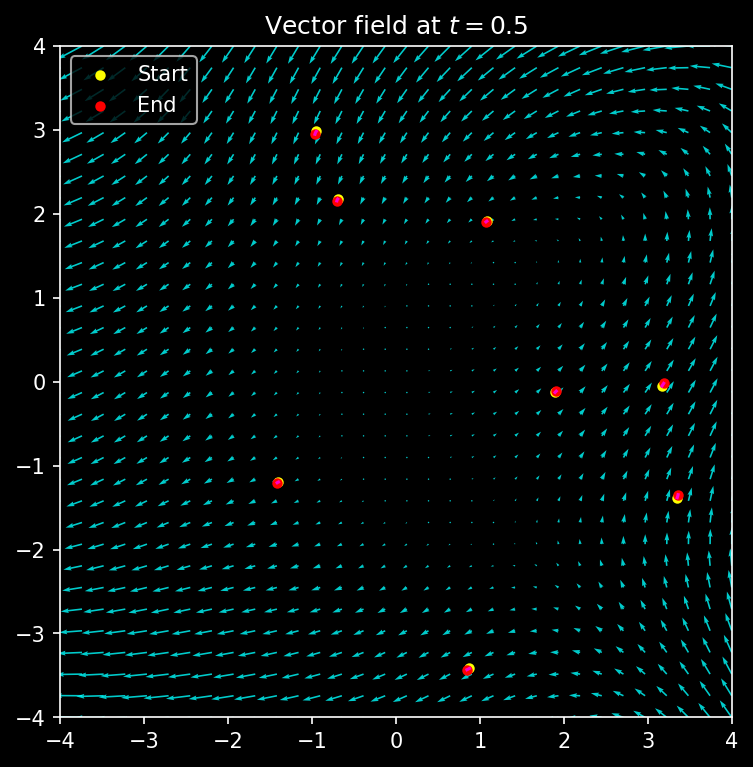

In [ ]:
# Visualize the vector field using a quiver plot

fig,ax = plt.subplots(1, 1, figsize=(5, 5), layout='constrained')

# Quiver plot
grid = np.linspace(-4, 4, 32)
xx, yy = np.meshgrid(grid, grid)
xy = np.stack([xx.ravel(), yy.ravel()], axis=1).astype('f4')

t_val = 0.5
t_batch = tf.fill([len(xy), 1], t_val)
uv = vector_field(xy, t_batch).numpy()

ax.quiver(
    xx, yy,
    uv[:, 0].reshape(xx.shape),
    uv[:, 1].reshape(xx.shape),
    color='cyan',
    alpha=0.8
)

# Calculate trajectories of 8 randomly chosen points
n_trajectories = 8
x0 = tf.random.uniform([n_trajectories,2]) * 8 - 4
t_trajectory = np.linspace(0, 1, 128)
x_t = integrate_rk45(vector_field, x0, solution_times=t_trajectory)
for xx,yy in x_t.numpy().transpose(1,2,0):
    ax.plot(xx, yy, color='magenta', alpha=0.8)

ax.scatter(x0[:, 0], x0[:, 1], color='yellow', s=16, label='Start')
ax.scatter(
    x_t.numpy()[-1,:,0],
    x_t.numpy()[-1,:,1],
    color='red', s=16,
    label='End'
)
ax.legend(loc='upper left')

# Plot formatting
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title(rf'Vector field at $t = {t_val}$')


plt.show()


## Flow matching

Flow Matching provides a way of training a continuous normalizing flow without having to solve any ODEs during training time. The key idea is to train the velocity field $\vec{v}(\vec{z}, t)$ to match the velocity of a path that transforms $\vec{x}$ into $\vec{y}$, where $\vec{y}$ is a sample from the target distribution. This path is defined by a simple linear interpolation between $\vec{x}$ and $\vec{y}$:
$$
  \vec{z}(t) = (1 - t) \vec{x} + t \vec{y}
$$
The velocity of this path is simply the difference between $\vec{y}$ and $\vec{x}$:
$$
  \frac{d\vec{z}(t)}{dt} = \vec{y} - \vec{x}
$$
The loss function for training the velocity field $\vec{v}$ is then defined as the mean squared error between the velocity of the path and the velocity predicted by the velocity field:
$$
  \mathcal{L}
  = \mathbb{E}_{\vec{x} \sim p(\vec{x}) ,\, \vec{y} \sim p(\vec{y}) ,\, t \sim U(0,1)} \left[
      \left\| \vec{v}(\vec{z}(t), t) - (\vec{y} - \vec{x}) \right\|^2
    \right]
$$

In [ ]:
def flow_matching_loss(x_1):
    """
    Compute the Flow Matching loss for one batch.

    Interpolated position:  x_t = (1 - t) * x_0 + t * x_1
    Target velocity:        u_t = x_1 - x_0   (constant along each path)

    Loss = E_{t, x_0, x_1} [ || v_theta(x_t, t) - u_t ||^2 ]

    Args:
        x_1:   (batch, n_dim) — samples from the target (data) distribution
    Returns:
        scalar loss tensor
    """
    batch_size = tf.shape(x_1)[0]

    # Sample source points x_0 ~ N(0, I)
    x_0 = tf.random.normal(tf.shape(x_1))

    # Sample time uniformly in [0, 1] — one value per sample
    t = tf.random.uniform(shape=(batch_size, 1), minval=0.0, maxval=1.0)

    # Interpolate: x_t = (1 - t) * x_0 + t * x_1
    x_t = (1.0 - t) * x_0 + t * x_1

    # Target velocity (straight-line path)
    u_t = x_1 - x_0

    # Predicted velocity
    v_t = vector_field(x_t, t)

    # Mean squared error loss
    loss = tf.reduce_mean(tf.reduce_sum((v_t - u_t) ** 2, axis=-1))
    return loss


# --- Quick demo: one forward pass ---
x_batch = tf.constant(y_train[:64])
loss_val = flow_matching_loss(x_batch)
print(f"Example Flow Matching loss (step 0, untrained): {loss_val.numpy():.4f}")

Example Flow Matching loss (step 0, untrained): 3.1353


In [ ]:
# Train the model on the crescent moons dataset

opt = tf.optimizers.Adam(learning_rate=1e-3)
n_epochs = 2048

iter = tqdm(range(n_epochs), desc="Training")

@tf.function
def loss_step():
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = flow_matching_loss(y_train)

    # Compute gradients and update model parameters
    grads = tape.gradient(loss, vector_field.trainable_variables)
    opt.apply_gradients(zip(grads, vector_field.trainable_variables))

    return loss

for epoch in iter:
    loss = loss_step()

    # Progress bar update
    iter.set_postfix({"loss": loss.numpy()})

Training:   0%|          | 0/2048 [00:00<?, ?it/s]

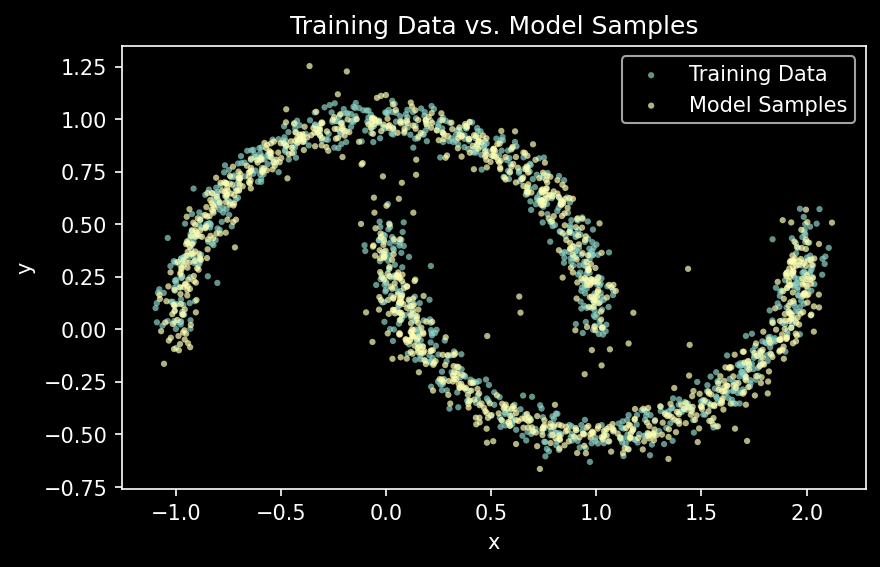

In [ ]:
# Generate samples: draw x_0 ~ N(0,I) then push forward to t=1
n_samples = 1024
x_0_samples = tf.random.normal((n_samples, n_dim))
x_1_samples = integrate_rk45(vector_field, x_0_samples)

kw = dict(s=9, alpha=0.7, edgecolors='none')
plt.scatter(
    y_train[:n_samples, 0],
    y_train[:n_samples, 1],
    label='Training Data', **kw
)
plt.scatter(
    x_1_samples[:, 0].numpy(),
    x_1_samples[:, 1].numpy(),
    label='Model Samples', **kw
)
plt.title("Training Data vs. Model Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

In [ ]:

graticule_positions = np.arange(-15, 15.01, 1.)
along_graticule = np.linspace(-15, 15, 1024)
x,y = np.meshgrid(
    graticule_positions,
    along_graticule,
    indexing='ij'
)
grat_const_x = np.stack([x.flat, y.flat], axis=1)
grat_const_y = np.stack([y.flat, x.flat], axis=1)
grat_xy = np.concatenate([grat_const_x, grat_const_y], axis=0).astype('f4')

def plot_graticules(ax, grat_array):
    # Extract and plot graticules
    n_grat = len(graticule_positions) * 2
    x = np.reshape(grat_array[...,0], (n_grat, -1))
    y = np.reshape(grat_array[...,1], (n_grat, -1))
    lines = []
    for xx,yy in zip(x,y):
        l, = ax.plot(xx, yy, color='#89CFF0', alpha=0.3, linewidth=0.5)
        lines.append(l)
    return lines

# plot_graticules(plt.gca(), grat_xy)
# plt.xlim(xlim)
# plt.ylim(ylim)
# plt.show()

In [ ]:
! mkdir frames

  0%|          | 0/300 [00:00<?, ?it/s]

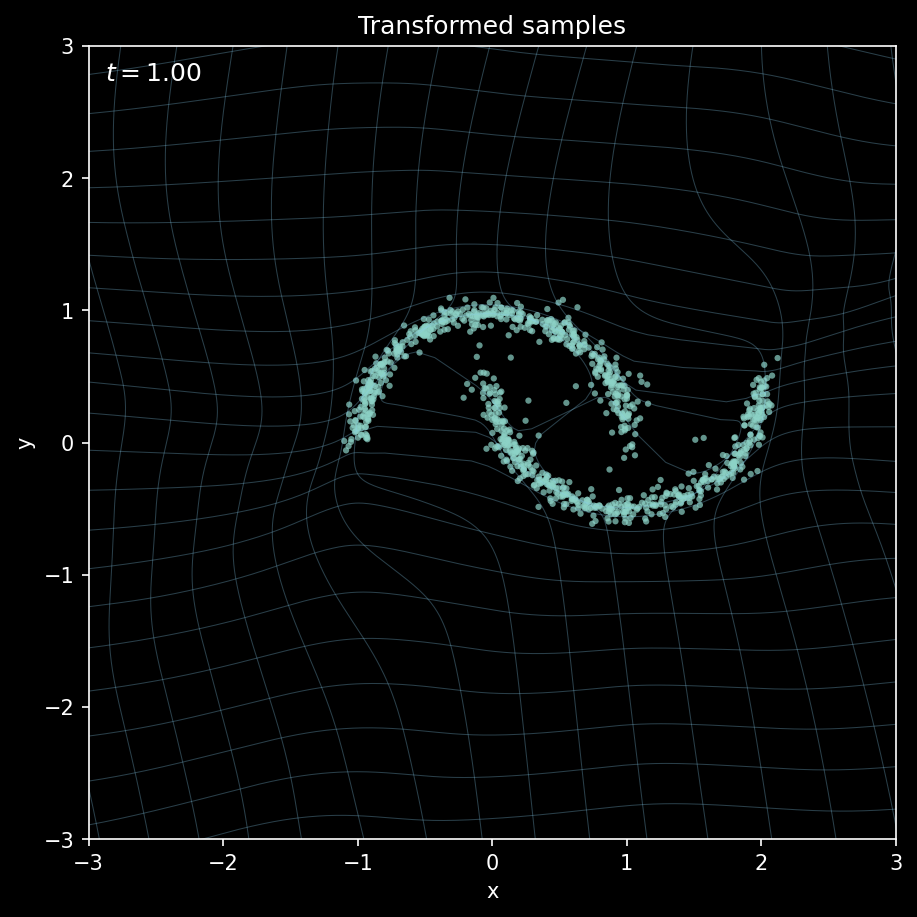

In [ ]:

# Generate an animation of the flow trajectories from t=0 to t=1,
# by returning multiple solution times from the ODE solver.

n_samples = 1024
n_frames = 300

t_range = np.linspace(0, 1, 32)

# Transform random samples
x_samples = tf.random.normal((n_samples, 2))
x_t_samples = integrate_rk45(
    vector_field, x_samples,
    solution_times=t_range
).numpy()

# Transform graticules
grat_xy_t = integrate_rk45(
    vector_field, grat_xy,
    solution_times=t_range
).numpy()

# Set up plot with y_train for scatterplot. Will update later.
fig,ax = plt.subplots(1,1, figsize=(6,6), layout='constrained')

# Start with training data, and save xlim, ylim
sc = ax.scatter(
    y_train[:, 0], y_train[:, 1],
    s=9, alpha=0.7, edgecolors='none'
)
grat_lines = plot_graticules(ax, grat_xy)
xlim = [-3, 3]
ylim = [-3, 3]

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Transformed samples')

# Create text object once; update it in the loop with set_text()
txt = ax.text(
    0.02, 0.98, r'$t = 0.00$',
    transform=ax.transAxes,
    fontsize=12,
    va='top', ha='left'
)

n_grat = len(graticule_positions) * 2

# Update t in a loop and save frames
for i in tqdm(range(n_frames)):
    # Interpolate t
    t_interp = np.interp(
        i/(n_frames-1),
        np.linspace(0, 1, len(t_range)),
        t_range
    )

    # Interpolate y samples
    i0 = np.searchsorted(t_range, t_interp) - 1
    i1 = i0 + 1
    w0 = (t_range[i1] - t_interp) / (t_range[i1] - t_range[i0])
    w1 = 1 - w0
    x_t_interp = w0 * x_t_samples[i0] + w1 * x_t_samples[i1]

    # Update scatterplot
    sc.set_offsets(x_t_interp)

    # Interpolate graticules and update each line in place
    grat_t_interp = w0 * grat_xy_t[i0] + w1 * grat_xy_t[i1]
    gx = np.reshape(grat_t_interp[:, 0], (n_grat, -1))
    gy = np.reshape(grat_t_interp[:, 1], (n_grat, -1))
    for line, xx, yy in zip(grat_lines, gx, gy):
        line.set_data(xx, yy)

    # Make sure the axes limits do not change
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Update text in place
    txt.set_text(rf'$t = {t_interp:>4.2f}$')

    # Save frame
    fn = f'frames/flow_{i:05d}.png'
    fig.savefig(fn)

plt.show()


In [ ]:
! ffmpeg -y \
    -framerate 30 \
    -i frames/flow_%05d.png \
    -vcodec libx264 \
    -profile:v baseline -level 3.0 \
    -pix_fmt yuv420p \
    -movflags +faststart \
    flow.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Conditional flow matching

In conditional flow matching, we model a distribution that is conditioned on some additional variable: $p(y\mid\theta)$. In this case, we will treat the Crescent Moons' noise parameter as the conditioning variable.

Everything works the same way as before, except that the velocity field is now a function of $\theta$ as well: $\vec{v}(\vec{z}, t, \theta)$.

In [ ]:
# Conditional version of the model, where the conditioning variable is continuous.
# For this example, we will again use the Moons dataset, conditional on the noise
# parameter.

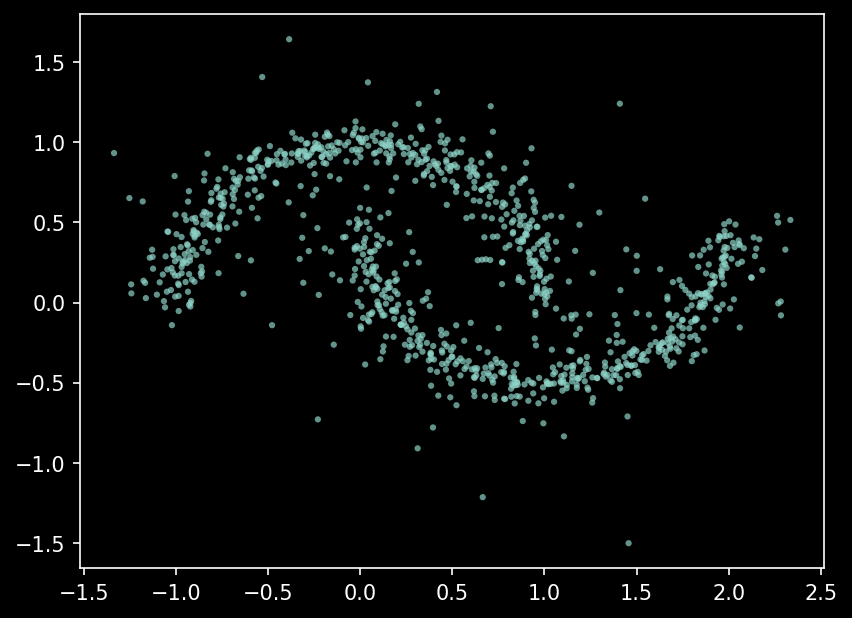

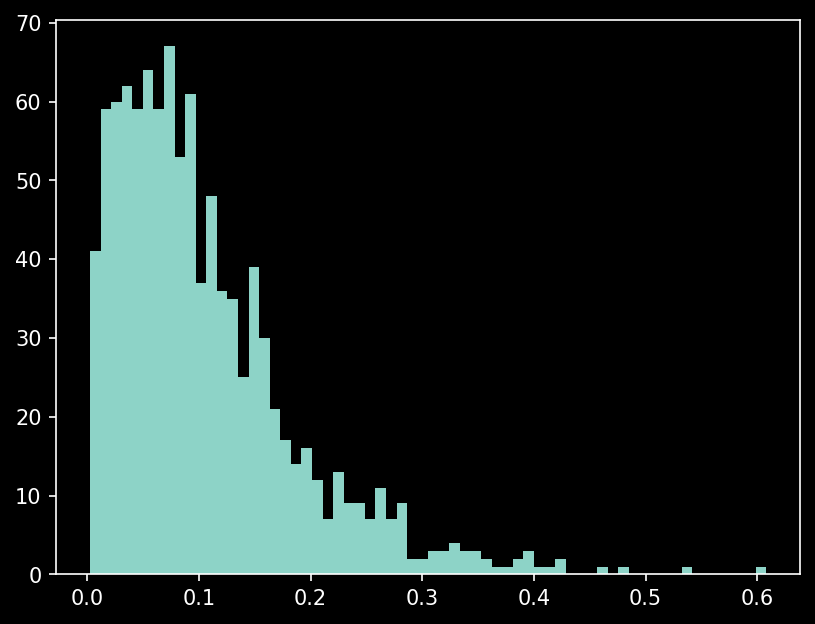

In [ ]:
rng = np.random.default_rng(seed=3)

def gen_conditional_training_data(n_samples):
    # Sample noise levels from a chi-square distribution (positive, heavy-tailed)
    y_sigma = 0.1 * rng.chisquare(df=3, size=n_samples) / 3

    # Generate noiseless moons data
    y_train,_ = make_moons(n_samples=n_samples, noise=0)

    # Add in noise
    y_train += y_sigma[:,None] * rng.normal(size=y_train.shape)

    # Use 32-bit floats for TensorFlow
    y_train = y_train.astype('f4')
    theta_train = np.reshape(y_sigma, (n_samples,1)).astype('f4')

    return y_train, theta_train

y_train, theta_train = gen_conditional_training_data(1024)

plt.scatter(y_train[:, 0], y_train[:, 1], s=9, alpha=0.7, edgecolors='none')
plt.show()

plt.hist(theta_train[:,0], bins=64)
plt.show()

In [ ]:
# Same as before, except that the MLP now takes
# a conditioning variable theta as well.

class ConditionalVectorField(snt.Module):
    """
    Simple MLP vector field v_theta(x_t, t, theta) for
    conditional Flow Matching.
    """

    def __init__(self, n_hidden, hidden_size,
                       n_dim_y, n_dim_theta,
                       name="conditional_vector_field"):
        super().__init__(name=name)
        self._mlp = snt.nets.MLP(
            output_sizes=n_hidden*[hidden_size]+[n_dim_y],
            activation=tf.nn.swish,
            activate_final=False
        )
        # Intialize the MLP variables by passing in dummy input
        x = tf.zeros((1,n_dim_y+1+n_dim_theta), dtype=tf.float32)
        self._mlp(x)

    def __call__(self, x_t, t, theta):
        """
        Args:
            x_t: (batch, n_dim_y)  — points along the path at time t
            t:   (batch, 1)        — time values in [0, 1]
            theta: (batch, n_dim_theta) — conditional parameters
        Returns:
            velocity: (batch, n_dim_y)
        """
        inputs = tf.concat([x_t, t, theta], axis=-1)
        return self._mlp(inputs)


In [ ]:
def integrate_rk45_conditional(model, x_0, theta):
    """
    Integrate the learned ODE from t=0 to t=1 using the Dormand-Prince
    RK45 adaptive step-size solver (from tensorflow_probability).

    Args:
        x_0: (batch, n_dim) — starting points sampled from the source N(0,I)
        theta: (batch, n_dim_theta) — conditioning variables to pass to the model
    Returns:
        x_1: (batch, n_dim) — approximate samples from the target distribution
    """
    def ode_fn(t, x):
        # The solver passes t as a scalar; expand to (batch, 1) for the MLP.
        t_batch = tf.fill((tf.shape(x)[0], 1), tf.cast(t, tf.float32))
        return model(x, t_batch, theta)

    solver = tfp.math.ode.DormandPrince()
    results = solver.solve(
        ode_fn,
        initial_time=0.0,
        initial_state=x_0,
        solution_times=[1.0],
    )
    # results.states has shape (n_solution_times, batch, n_dim); take t=1
    return results.states[0]

In [ ]:
# Instantiate the model
conditional_vector_field = ConditionalVectorField(
    n_hidden=5,
    hidden_size=128,
    n_dim_y=2,
    n_dim_theta=1
)

In [ ]:
def conditional_flow_matching_loss(x_1, theta):
    """
    Compute the (conditional) Flow Matching loss for one mini-batch.

    Conditional flow:  x_t = (1 - t) * x_0 + t * x_1
    Target velocity:   u_t = x_1 - x_0   (constant along each path)

    Loss = E_{t, x_0, x_1} [ || v_theta(x_t, t) - u_t ||^2 ]

    Args:
        x_1:   (batch, n_dim) — samples from the target (data) distribution
        theta: (batch, n_dim_theta) — conditional parameters
    Returns:
        scalar loss tensor
    """
    batch_size = tf.shape(x_1)[0]

    # Sample source points x_0 ~ N(0, I)
    x_0 = tf.random.normal(tf.shape(x_1))

    # Sample time uniformly in [0, 1] — one value per sample
    t = tf.random.uniform(shape=(batch_size, 1), minval=0.0, maxval=1.0)

    # Interpolate: x_t = (1 - t) * x_0 + t * x_1
    x_t = (1.0 - t) * x_0 + t * x_1

    # Conditional target velocity (straight-line path)
    u_t = x_1 - x_0

    # Predicted velocity
    v_t = conditional_vector_field(x_t, t, theta)

    # Mean squared error loss
    loss = tf.reduce_mean(tf.reduce_sum((v_t - u_t) ** 2, axis=-1))
    return loss


# --- Quick demo: one forward pass ---
x_batch = tf.constant(y_train[:64])
theta_batch = tf.constant(theta_train[:64])  # Example conditional parameters
loss_val = conditional_flow_matching_loss(x_batch, theta_batch)
print(f"Example Flow Matching loss (step 0, untrained): {loss_val.numpy():.4f}")

Example Flow Matching loss (step 0, untrained): 2.8498


In [ ]:
# Train the model on the conditional crescent moons dataset

n_epochs = 1024 * 2
batch_size = 1024 * 4

opt = tf.optimizers.Adam(learning_rate=1e-3)
variables = conditional_vector_field.trainable_variables

iter = tqdm(range(n_epochs), desc="Training")

@tf.function
def conditional_loss_step(y_train, theta_train):
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = conditional_flow_matching_loss(y_train, theta_train)

    # Compute gradients and update model parameters
    grads = tape.gradient(loss, variables)
    opt.apply_gradients(zip(grads, variables))

    return loss

for epoch in iter:
    # Generate training data for this epoch (reshuffle noise levels)
    y_train, theta_train = gen_conditional_training_data(batch_size)

    loss = conditional_loss_step(y_train, theta_train)

    # Progress bar update
    iter.set_postfix({"loss": loss.numpy()})

Training:   0%|          | 0/2048 [00:00<?, ?it/s]

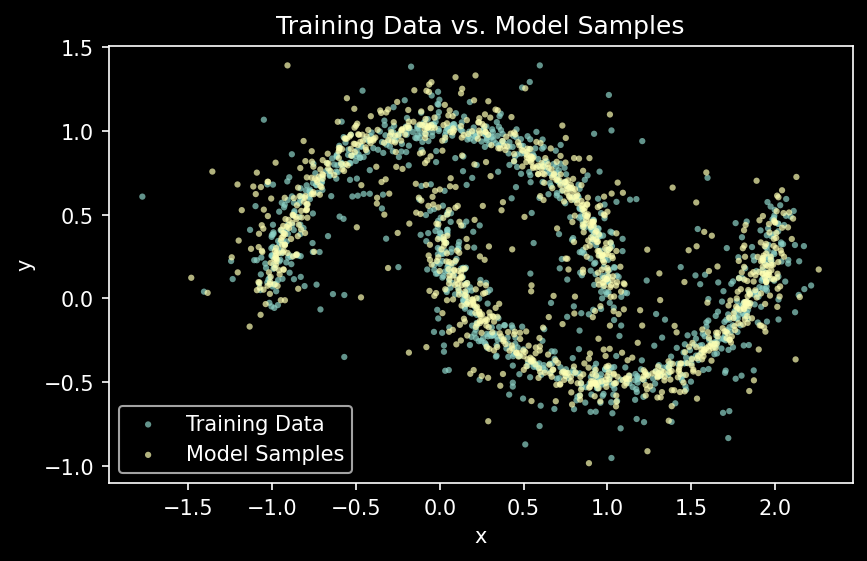

In [ ]:
# Generate samples: draw x_0 ~ N(0,I) then push forward to t=1
n_samples = 1024
x_0_samples = tf.random.normal((n_samples, n_dim))
theta_samples = 0.1 * rng.chisquare(df=3, size=(n_samples,1)).astype('f4')/3
x_1_samples = integrate_rk45_conditional(
    conditional_vector_field,
    x_0_samples,
    theta_samples
)

kw = dict(s=9, alpha=0.7, edgecolors='none')
plt.scatter(
    y_train[:n_samples, 0],
    y_train[:n_samples, 1],
    label='Training Data', **kw
)
plt.scatter(
    x_1_samples[:, 0].numpy(),
    x_1_samples[:, 1].numpy(),
    label='Model Samples', **kw
)
plt.title("Training Data vs. Model Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

In [ ]:

# Generate family of trajectories with varying noise levels
# Generate samples: draw x_0 ~ N(0,I) then push forward to t=1
n_samples = 1024
x_0_samples = tf.random.normal((n_samples, n_dim))

theta_range = np.linspace(0.01, 0.4, 32).astype('f4')

y_of_theta = []
grat_xy_of_theta = []

for theta in tqdm(theta_range):
    theta_tf = tf.fill([n_samples, 1], theta)
    y = integrate_rk45_conditional(
        conditional_vector_field,
        x_0_samples,
        theta_tf
    )
    y_of_theta.append(y.numpy())

    grat_theta_tf = tf.fill([len(grat_xy), 1], theta)
    g = integrate_rk45_conditional(
        conditional_vector_field,
        grat_xy,
        grat_theta_tf
    )
    grat_xy_of_theta.append(g.numpy())

y_of_theta = np.stack(y_of_theta, axis=0)            # Shape: (n_theta, batch, n_dim)
grat_xy_of_theta = np.stack(grat_xy_of_theta, axis=0)  # Shape: (n_theta, n_grat_pts, n_dim)


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

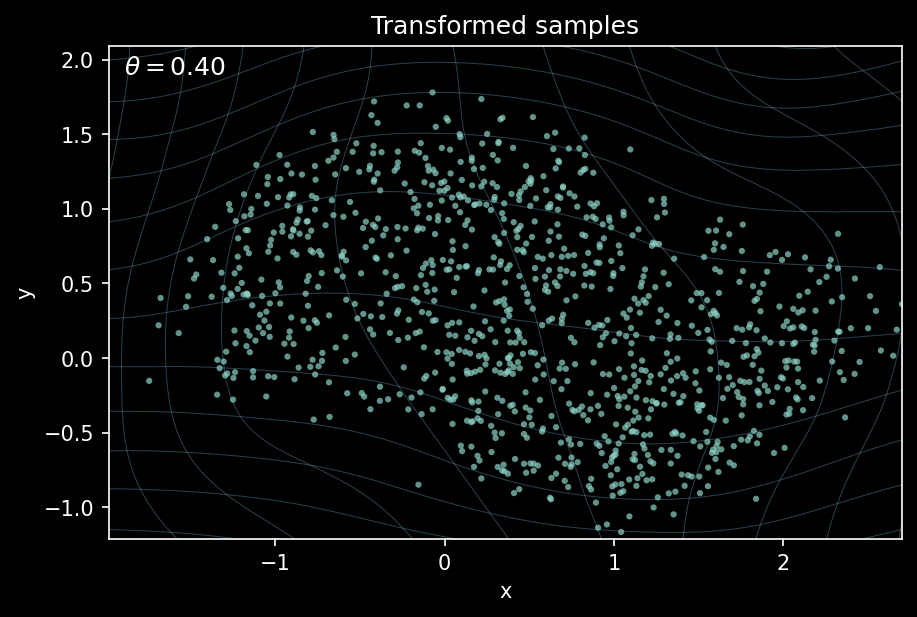

In [ ]:

# Scatterplot of y_of_theta for different theta values.
# We will update the plot in a loop and save the frames.
# Linear interpolation between the theta values to create a smooth animation.

n_frames = 300
n_grat = len(graticule_positions) * 2

fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

sc = ax.scatter(
    y_train[:, 0], y_train[:, 1],
    s=9, alpha=0.7, edgecolors='none'
)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
grat_lines = plot_graticules(ax, grat_xy_of_theta[0])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Transformed samples')

# Create text object once; update it in the loop with set_text()
txt = ax.text(
    0.02, 0.98, r'$\theta = 0.01$',
    transform=ax.transAxes,
    fontsize=12,
    va='top', ha='left'
)

# Update theta in a loop and save frames
for i in tqdm(range(n_frames)):
    # Interpolate theta
    theta_interp = np.interp(
        i / (n_frames - 1),
        np.linspace(0, 1, len(theta_range)),
        theta_range
    )

    i0 = np.searchsorted(theta_range, theta_interp) - 1
    i1 = i0 + 1
    w0 = (theta_range[i1] - theta_interp) / (theta_range[i1] - theta_range[i0])
    w1 = 1 - w0

    # Update scatterplot
    y_interp = w0 * y_of_theta[i0] + w1 * y_of_theta[i1]
    sc.set_offsets(y_interp)

    # Interpolate graticules and update each line in place
    grat_interp = w0 * grat_xy_of_theta[i0] + w1 * grat_xy_of_theta[i1]
    gx = np.reshape(grat_interp[:, 0], (n_grat, -1))
    gy = np.reshape(grat_interp[:, 1], (n_grat, -1))
    for line, xx, yy in zip(grat_lines, gx, gy):
        line.set_data(xx, yy)

    # Make sure the axes limits do not change
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Update text in place
    txt.set_text(rf'$\theta = {theta_interp:>4.2f}$')

    # Save frame
    fn = f'frames/conditional_flow_{i:05d}.png'
    fig.savefig(fn)

plt.show()


In [ ]:
! ffmpeg -y \
    -framerate 30 \
    -i frames/conditional_flow_%05d.png \
    -vcodec libx264 \
    -profile:v baseline -level 3.0 \
    -pix_fmt yuv420p \
    -movflags +faststart \
    conditional_flow.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab